In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
metadata_df = pd.read_csv("/content/drive/MyDrive/project_dataset/HAM10000_metadata.csv")

In [ ]:
metadata_df

,lesion_id,image_id,dx,dx_type,age,sex,localization
0,HAM_0000118,ISIC_0027419,bkl,histo,80.0,male,scalp
1,HAM_0000118,ISIC_0025030,bkl,histo,80.0,male,scalp
2,HAM_0002730,ISIC_0026769,bkl,histo,80.0,male,scalp
3,HAM_0002730,ISIC_0025661,bkl,histo,80.0,male,scalp
4,HAM_0001466,ISIC_0031633,bkl,histo,75.0,male,ear
...,...,...,...,...,...,...,...
10010,HAM_0002867,ISIC_0033084,akiec,histo,40.0,male,abdomen
10011,HAM_0002867,ISIC_0033550,akiec,histo,40.0,male,abdomen
10012,HAM_0002867,ISIC_0033536,akiec,histo,40.0,male,abdomen
10013,HAM_0000239,ISIC_0032854,akiec,histo,80.0,male,face


<ipython-input-5-303775763ecf>:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='dx', data=metadata_df, palette='Set2')


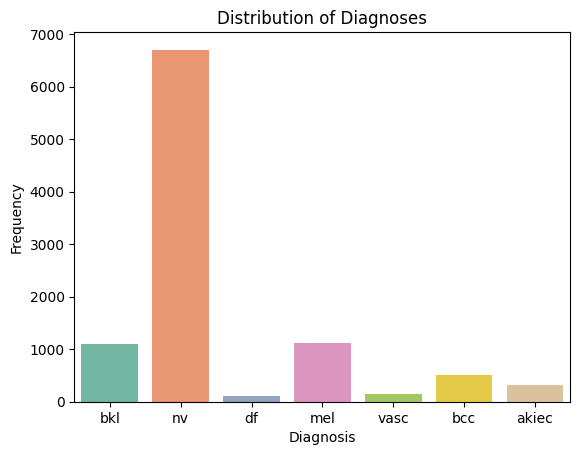

In [ ]:
sns.countplot(x='dx', data=metadata_df, palette='Set2')
plt.title('Distribution of Diagnoses')
plt.xlabel('Diagnosis')
plt.ylabel('Frequency')
plt.show()

In [ ]:
metadata_df["dx"].value_counts()

,count
dx,
nv,6705
mel,1113
bkl,1099
bcc,514
akiec,327
vasc,142
df,115


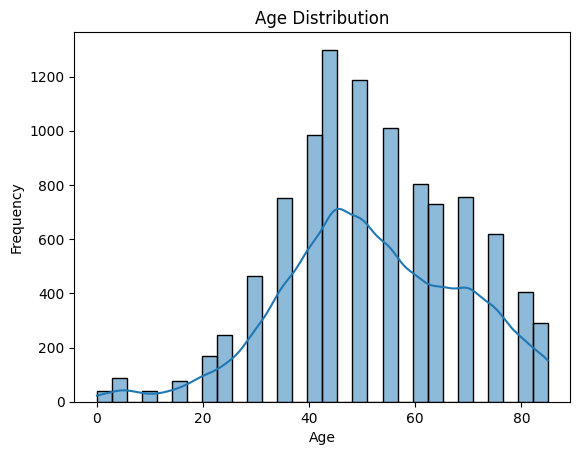

In [ ]:
# Histogram
sns.histplot(metadata_df['age'], kde=True, bins=30)
plt.title('Age Distribution')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.show()

<ipython-input-8-ae74ef7b865f>:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='dx', y='age', data=metadata_df, palette='Set3')


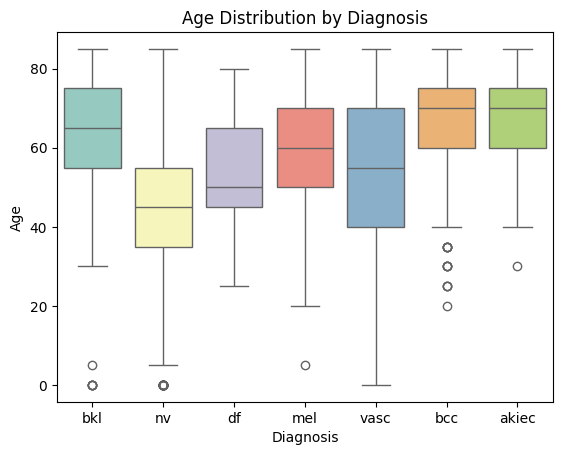

In [ ]:
# Box Plot
sns.boxplot(x='dx', y='age', data=metadata_df, palette='Set3')
plt.title('Age Distribution by Diagnosis')
plt.xlabel('Diagnosis')
plt.ylabel('Age')
plt.show()

In [ ]:
data = pd.read_csv("/content/drive/MyDrive/project_dataset/hmnist_28_28_RGB.csv")

In [ ]:
data.sample(7)

,pixel0000,pixel0001,pixel0002,pixel0003,pixel0004,pixel0005,pixel0006,pixel0007,pixel0008,pixel0009,...,pixel2343,pixel2344,pixel2345,pixel2346,pixel2347,pixel2348,pixel2349,pixel2350,pixel2351,label
7032,182,166,174,183,167,177,183,168,178,183,...,176,159,167,176,159,168,174,157,164,4
9245,206,170,179,203,161,165,201,154,157,203,...,199,158,166,196,154,155,196,156,159,4
3967,233,154,175,232,150,172,229,150,169,227,...,212,136,147,211,136,148,209,137,147,4
3379,234,178,196,233,178,195,233,176,195,231,...,228,181,193,227,181,193,224,179,192,4
4367,231,142,142,234,144,146,235,146,147,237,...,229,155,145,227,153,147,226,150,145,4
9222,173,141,147,177,145,151,180,148,156,182,...,178,145,156,175,142,151,173,142,150,4
3407,233,153,136,238,160,141,244,163,144,246,...,240,168,140,239,170,144,237,171,150,4


In [ ]:
data["label"].value_counts()

,count
label,
4,6705
6,1113
2,1099
1,514
0,327
5,142
3,115


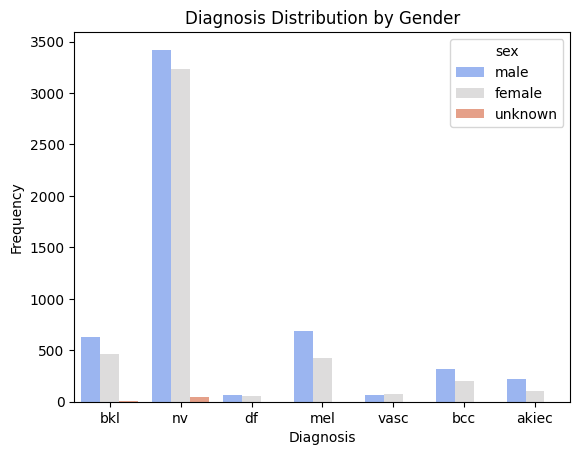

In [ ]:
sns.countplot(x='dx', hue='sex', data=metadata_df, palette='coolwarm')
plt.title('Diagnosis Distribution by Gender')
plt.xlabel('Diagnosis')
plt.ylabel('Frequency')
plt.show()

<ipython-input-13-1daf47811820>:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y='localization', data=metadata_df, palette='viridis', order=metadata_df['localization'].value_counts().index)


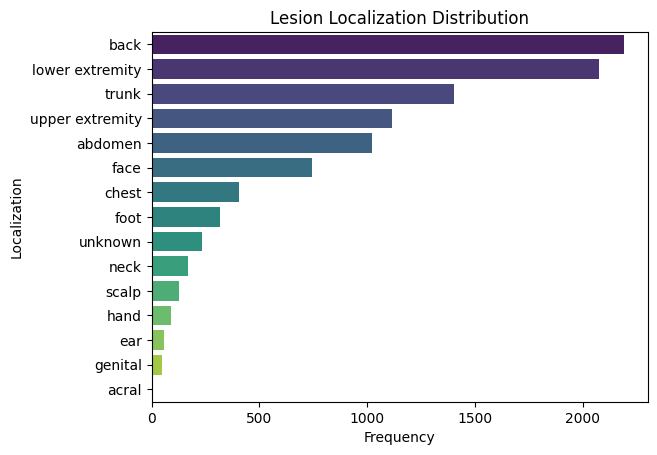

In [ ]:
sns.countplot(y='localization', data=metadata_df, palette='viridis', order=metadata_df['localization'].value_counts().index)
plt.title('Lesion Localization Distribution')
plt.xlabel('Frequency')
plt.ylabel('Localization')
plt.show()

In [ ]:
metadata_df['gender_encoded'] = metadata_df['sex'].map({'male': 0, 'female': 1})

In [ ]:
metadata_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10015 entries, 0 to 10014
Data columns (total 8 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   lesion_id       10015 non-null  object 
 1   image_id        10015 non-null  object 
 2   dx              10015 non-null  object 
 3   dx_type         10015 non-null  object 
 4   age             9958 non-null   float64
 5   sex             10015 non-null  object 
 6   localization    10015 non-null  object 
 7   gender_encoded  9958 non-null   float64
dtypes: float64(2), object(6)
memory usage: 626.1+ KB


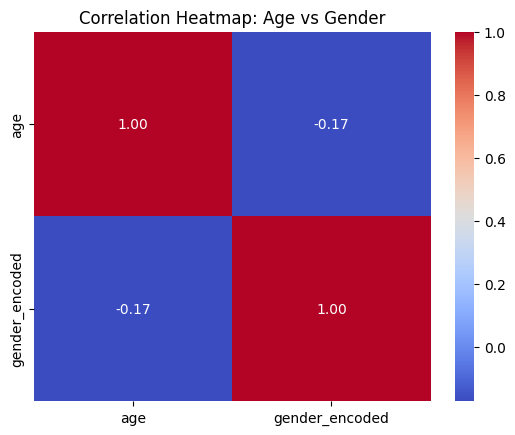

In [ ]:
correlation = metadata_df[["age", "gender_encoded"]].corr()
sns.heatmap(correlation, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap: Age vs Gender')
plt.show()

<ipython-input-17-c987fc0b024f>:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='dx', y='age', data=metadata_df, palette='Set1')


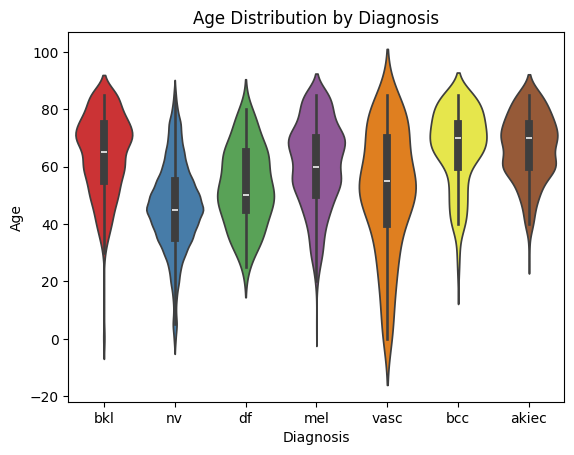

In [ ]:
sns.violinplot(x='dx', y='age', data=metadata_df, palette='Set1')
plt.title('Age Distribution by Diagnosis')
plt.xlabel('Diagnosis')
plt.ylabel('Age')
plt.show()


<ipython-input-18-ec7f0711d8dc>:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='dx_type', data=metadata_df, palette='Set2')


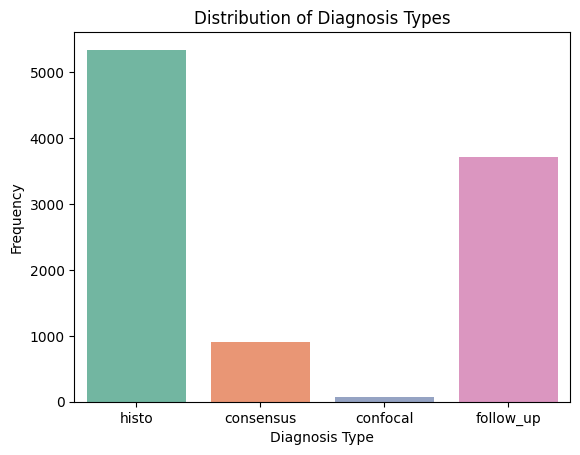

In [ ]:
sns.countplot(x='dx_type', data=metadata_df, palette='Set2')
plt.title('Distribution of Diagnosis Types')
plt.xlabel('Diagnosis Type')
plt.ylabel('Frequency')
plt.show()

In [ ]:
data.sample(10)

,pixel0000,pixel0001,pixel0002,pixel0003,pixel0004,pixel0005,pixel0006,pixel0007,pixel0008,pixel0009,...,pixel2343,pixel2344,pixel2345,pixel2346,pixel2347,pixel2348,pixel2349,pixel2350,pixel2351,label
9653,203,162,183,207,164,183,208,168,187,212,...,219,181,207,218,179,205,217,178,204,4
7141,155,136,149,160,143,158,165,148,165,167,...,173,157,170,171,155,170,164,142,157,4
5146,213,125,146,213,124,146,214,126,148,217,...,203,127,139,203,128,140,199,123,132,4
2702,181,129,114,196,150,137,193,143,124,184,...,161,117,100,148,96,72,142,91,61,1
8245,211,166,190,211,163,181,208,158,170,205,...,204,159,183,198,154,175,193,149,172,4
8323,187,145,154,190,148,155,195,151,160,203,...,182,130,126,184,133,131,204,155,164,4
1813,0,0,0,0,0,0,0,0,0,3,...,3,1,2,1,1,2,0,0,0,6
5793,240,164,165,240,163,166,240,164,171,236,...,221,153,146,218,150,146,213,145,142,4
1713,171,137,134,177,141,139,181,145,144,185,...,179,144,148,173,138,141,166,131,131,6
5062,235,158,158,237,160,162,237,161,166,237,...,224,148,141,213,138,132,206,129,122,4


In [ ]:
data.shape

(10015, 2353)

In [ ]:
Data = data.drop(columns=["label"])
Label = data['label']

In [ ]:
Label

,label
0,2
1,2
2,2
3,2
4,2
...,...
10010,0
10011,0
10012,0
10013,0


In [ ]:
from imblearn.over_sampling import RandomOverSampler

oversample = RandomOverSampler()
Data, Label = oversample.fit_resample(Data, Label)
Data = np.array(Data).reshape(-1, 28, 28, 3)
print('Shape of Data :', Data.shape)

Shape of Data : (46935, 28, 28, 3)


In [ ]:
Label = np.array(Label)
#Label = np.append(Label, 7) #to add the "uk" condition #this leads to inconsistent samples further in the train_test_split
Label.shape

(46935,)

In [ ]:
label_association = {4: ('nv', ' melanocytic nevi'),
           6: ('mel', 'melanoma'),
           2 :('bkl', 'benign keratosis-like lesions'),
           1:('bcc' , ' basal cell carcinoma'),
           5: ('vasc', ' pyogenic granulomas and hemorrhage'),
           0: ('akiec', 'Actinic keratoses and intraepithelial carcinomae'),
           3: ('df', 'dermatofibroma')
}

# Splitting Data

In [ ]:
from sklearn.model_selection import train_test_split

X_train , X_test , y_train , y_test = train_test_split(Data , Label , test_size = 0.20 , random_state = 50)

In [ ]:
print(X_train.shape)
print(y_train.shape)
print(X_test.shape)
print(y_test.shape)

(37548, 28, 28, 3)
(37548,)
(9387, 28, 28, 3)
(9387,)


In [ ]:
from keras.utils import to_categorical

y_train = to_categorical(y_train)
y_test = to_categorical(y_test)

In [ ]:
y_train.shape
y_test.shape

(9387, 7)

In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
datagen = ImageDataGenerator(rescale=(1./255) #rescaling is done to reduce the pixel values to [0,1]. This is a common step for neural networks and brings the values into a suitable range for training
                             ,rotation_range=10 #this applies random rotations upto 10 degrees in either direction. This makes the training data better and helps the model become robust.
                             ,zoom_range = 0.1 #the image will be zoomed in or out by 10%. This helps the model to learn to recognize objects from different perspectives and scales.
                             ,width_shift_range=0.1 #these both control Vertical and horizontal ships of the images upto 10%. This helps the model to handle variations of objects in the images.
                             ,height_shift_range=0.1)

testgen = ImageDataGenerator(rescale=(1./255)) # This ensures that the test data is pre-processed in the same way as the training data.

In [ ]:
from keras.callbacks import ReduceLROnPlateau
learning_rate_reduction = ReduceLROnPlateau(monitor='val_accuracy' #monitors the validation accuracy
                                            , patience = 2 #de








                                            termines how many consecutive epochs of no improvement in the monitored metric (val_accuracy in this case) will trigger the learning rate reduction.
                                            , verbose=1 #this means that Messages about learning rate reduction will be printed to the console.
                                            ,factor=0.5 # This specifies how much the learning rate should be reduced when the specified condition is met. In our case learning rate will be halved
                                            , min_lr=0.00001) #This sets the lower bound for the learning rate.

In [ ]:
from tensorflow import keras
from tensorflow.keras.optimizers import Adam, Adamax
modelA = keras.models.Sequential()

# Create Model Structure
modelA.add(keras.layers.Input(shape=[28, 28, 3])) #this layer defines the shape of the input data. Image is of size 28x28 pixels and 3 colour channels (RGB)
modelA.add(keras.layers.Conv2D(32, (3, 3), activation='relu', padding='same', kernel_initializer='he_normal')) #convulutional layers extract features.
modelA.add(keras.layers.MaxPooling2D()) #these layers reduce the spatial dimensions of the feature maps while retaining the most important information. They help make the network more robust to variations in the input.
modelA.add(keras.layers.BatchNormalization())# these layers normalize the activations of the previous layer.

modelA.add(keras.layers.Conv2D(64, (3, 3), activation='relu', padding='same', kernel_initializer='he_normal'))
modelA.add(keras.layers.Conv2D(64, (3, 3), activation='relu', padding='same', kernel_initializer='he_normal'))
modelA.add(keras.layers.MaxPooling2D())
modelA.add(keras.layers.BatchNormalization())
modelA.add(keras.layers.Conv2D(128, (3, 3), activation='relu', padding='same', kernel_initializer='he_normal'))
modelA.add(keras.layers.Conv2D(128, (3, 3), activation='relu', padding='same', kernel_initializer='he_normal'))
modelA.add(keras.layers.MaxPooling2D())
modelA.add(keras.layers.BatchNormalization())

modelA.add(keras.layers.Conv2D(256, (3, 3), activation='relu', padding='same', kernel_initializer='he_normal'))
modelA.add(keras.layers.Conv2D(256, (3, 3), activation='relu', padding='same', kernel_initializer='he_normal'))
modelA.add(keras.layers.MaxPooling2D())

modelA.add(keras.layers.Flatten()) #flattens the 2D feature maps from convolutional layers into a 1D vector.
modelA.add(keras.layers.Dropout(rate=0.2)) #this layer prevents overfitting by randomly deactivating a fraction of neurons.
modelA.add(keras.layers.Dense(units=256, activation='relu', kernel_initializer='he_normal')) #these layers recieve the flattened feature vector and provides outputs for each classes.
modelA.add(keras.layers.BatchNormalization())

modelA.add(keras.layers.Dense(units=128, activation='relu', kernel_initializer='he_normal'))
modelA.add(keras.layers.BatchNormalization())

modelA.add(keras.layers.Dense(units=64, activation='relu', kernel_initializer='he_normal'))
modelA.add(keras.layers.BatchNormalization())

modelA.add(keras.layers.Dense(units=32, activation='relu', kernel_initializer='he_normal', kernel_regularizer=keras.regularizers.L1L2()))
modelA.add(keras.layers.BatchNormalization())

modelA.add(keras.layers.Dense(units=7, activation='softmax', kernel_initializer='glorot_uniform', name='classifier')) # this is the ouptput layer which classifies output into class probabilities.
modelA.compile(Adamax(learning_rate= 0.001), loss= 'categorical_crossentropy', metrics= ['accuracy'])

modelA.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 28, 28, 32)          │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 14, 14, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization                  │ (None, 14, 14, 32)          │             128 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 14, 14, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 14, 14, 64)          │          36,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 7, 7, 64)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_1                │ (None, 7, 7, 64)            │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_3 (Conv2D)                    │ (None, 7, 7, 128)           │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_4 (Conv2D)                    │ (None, 7, 7, 128)           │         147,584 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 3, 3, 128)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_2                │ (None, 3, 3, 128)           │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_5 (Conv2D)                    │ (None, 3, 3, 256)           │         295,168 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_6 (Conv2D)                    │ (None, 3, 3, 256)           │         590,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_3 (MaxPooling2D)       │ (None, 1, 1, 256)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 256)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 256)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 256)                 │          65,792 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_3                │ (None, 256)                 │           1,024 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 128)                 │          32,896 │
├──────────────────────────────────────┼─────────────────────────────┼──────────────

 Total params: 1,275,079 (4.86 MB)

 Trainable params: 1,273,671 (4.86 MB)

 Non-trainable params: 1,408 (5.50 KB)

In [ ]:
import tensorflow as tf
# Mean Squared Error (MSE)
loss_mse = tf.keras.losses.MeanSquaredError()

# Leaky ReLU
activation_leaky_relu = tf.keras.layers.LeakyReLU(alpha=0.01)

# Truncated Normal
initializer_truncated_normal = tf.keras.initializers.TruncatedNormal()

modelB = keras.models.Sequential()

# Create Model Structure
modelB.add(keras.layers.Input(shape=[28, 28, 3])) #this layer defines the shape of the input data. Image is of size 28x28 pixels and 3 colour channels (RGB)
modelB.add(keras.layers.Conv2D(32, (3, 3), activation=activation_leaky_relu, padding='same', kernel_initializer=initializer_truncated_normal)) #convulutional layers extract features.
modelB.add(keras.layers.MaxPooling2D()) #these layers reduce the spatial dimensions of the feature maps while retaining the most important information. They help make the network more robust to variations in the input.
modelB.add(keras.layers.BatchNormalization())# these layers normalize the activations of the previous layer.

modelB.add(keras.layers.Conv2D(64, (3, 3), activation=activation_leaky_relu, padding='same', kernel_initializer=initializer_truncated_normal))
modelB.add(keras.layers.Conv2D(64, (3, 3), activation=activation_leaky_relu, padding='same', kernel_initializer=initializer_truncated_normal))
modelB.add(keras.layers.MaxPooling2D())
modelB.add(keras.layers.BatchNormalization())
modelB.add(keras.layers.Conv2D(128, (3, 3), activation=activation_leaky_relu, padding='same', kernel_initializer=initializer_truncated_normal))
modelB.add(keras.layers.Conv2D(128, (3, 3), activation=activation_leaky_relu, padding='same', kernel_initializer=initializer_truncated_normal))
modelB.add(keras.layers.MaxPooling2D())
modelB.add(keras.layers.BatchNormalization())

modelB.add(keras.layers.Conv2D(256, (3, 3), activation=activation_leaky_relu, padding='same', kernel_initializer=initializer_truncated_normal))
modelB.add(keras.layers.Conv2D(256, (3, 3), activation=activation_leaky_relu, padding='same', kernel_initializer=initializer_truncated_normal))
modelB.add(keras.layers.MaxPooling2D())

modelB.add(keras.layers.Flatten()) #flattens the 2D feature maps from convolutional layers into a 1D vector.
modelB.add(keras.layers.Dropout(rate=0.2)) #this layer prevents overfitting by randomly deactivating a fraction of neurons.
modelB.add(keras.layers.Dense(units=256, activation=activation_leaky_relu, kernel_initializer=initializer_truncated_normal)) #these layers recieve the flattened feature vector and provides outputs for each classes.
modelB.add(keras.layers.BatchNormalization())

modelB.add(keras.layers.Dense(units=128, activation=activation_leaky_relu, kernel_initializer=initializer_truncated_normal))
modelB.add(keras.layers.BatchNormalization())

modelB.add(keras.layers.Dense(units=64, activation=activation_leaky_relu, kernel_initializer=initializer_truncated_normal))
modelB.add(keras.layers.BatchNormalization())

modelB.add(keras.layers.Dense(units=32, activation=activation_leaky_relu, kernel_initializer=initializer_truncated_normal, kernel_regularizer=keras.regularizers.L1L2()))
modelB.add(keras.layers.BatchNormalization())

modelB.add(keras.layers.Dense(units=7, activation='softmax', kernel_initializer='glorot_uniform', name='classifier')) # this is the ouptput layer which classifies output into class probabilities.
modelB.compile(Adamax(learning_rate= 0.001), loss= loss_mse, metrics= ['accuracy'])

modelB.summary()

/usr/local/lib/python3.10/dist-packages/keras/src/layers/activations/leaky_relu.py:41: UserWarning: Argument `alpha` is deprecated. Use `negative_slope` instead.
  warnings.warn(


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d_7 (Conv2D)                    │ (None, 28, 28, 32)          │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_4 (MaxPooling2D)       │ (None, 14, 14, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_7                │ (None, 14, 14, 32)          │             128 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_8 (Conv2D)                    │ (None, 14, 14, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_9 (Conv2D)                    │ (None, 14, 14, 64)          │          36,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_5 (MaxPooling2D)       │ (None, 7, 7, 64)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_8                │ (None, 7, 7, 64)            │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_10 (Conv2D)                   │ (None, 7, 7, 128)           │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_11 (Conv2D)                   │ (None, 7, 7, 128)           │         147,584 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_6 (MaxPooling2D)       │ (None, 3, 3, 128)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_9                │ (None, 3, 3, 128)           │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_12 (Conv2D)                   │ (None, 3, 3, 256)           │         295,168 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_13 (Conv2D)                   │ (None, 3, 3, 256)           │         590,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_7 (MaxPooling2D)       │ (None, 1, 1, 256)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_1 (Flatten)                  │ (None, 256)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 256)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_4 (Dense)                      │ (None, 256)                 │          65,792 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_10               │ (None, 256)                 │           1,024 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_5 (Dense)                      │ (None, 128)                 │          32,896 │
├──────────────────────────────────────┼─────────────────────────────┼──────────────

 Total params: 1,275,079 (4.86 MB)

 Trainable params: 1,273,671 (4.86 MB)

 Non-trainable params: 1,408 (5.50 KB)

In [ ]:
historyA = modelA.fit(X_train,
                    y_train,
                    epochs=10,
                    batch_size=128,
                    validation_data=(X_test , y_test),
                    callbacks=[learning_rate_reduction])

Epoch 1/10
294/294 ━━━━━━━━━━━━━━━━━━━━ 259s 859ms/step - accuracy: 0.4577 - loss: 1.4771 - val_accuracy: 0.6770 - val_loss: 0.8622 - learning_rate: 0.0010
Epoch 2/10
294/294 ━━━━━━━━━━━━━━━━━━━━ 260s 852ms/step - accuracy: 0.8225 - loss: 0.5295 - val_accuracy: 0.8780 - val_loss: 0.3287 - learning_rate: 0.0010
Epoch 3/10
294/294 ━━━━━━━━━━━━━━━━━━━━ 254s 864ms/step - accuracy: 0.9075 - loss: 0.2850 - val_accuracy: 0.9219 - val_loss: 0.2164 - learning_rate: 0.0010
Epoch 4/10
294/294 ━━━━━━━━━━━━━━━━━━━━ 255s 842ms/step - accuracy: 0.9350 - loss: 0.1929 - val_accuracy: 0.9273 - val_loss: 0.2112 - learning_rate: 0.0010
Epoch 5/10
294/294 ━━━━━━━━━━━━━━━━━━━━ 249s 847ms/step - accuracy: 0.9527 - loss: 0.1396 - val_accuracy: 0.9579 - val_loss: 0.1296 - learning_rate: 0.0010
Epoch 6/10
294/294 ━━━━━━━━━━━━━━━━━━━━ 263s 853ms/step - accuracy: 0.9637 - loss: 0.1087 - val_accuracy: 0.9586 - val_loss: 0.1255 - learning_rate: 0.0010
Epoch 7/10
294/294 ━━━━━━━━━━━━━━━━━━━━ 257s 876ms/step - accura

In [ ]:
historyB = modelB.fit(X_train,
                    y_train,
                    epochs=10,
                    batch_size=128,
                    validation_data=(X_test , y_test),
                    callbacks=[learning_rate_reduction])

Epoch 1/10
294/294 ━━━━━━━━━━━━━━━━━━━━ 256s 852ms/step - accuracy: 0.4118 - loss: 0.1027 - val_accuracy: 0.4799 - val_loss: 0.0951 - learning_rate: 0.0010
Epoch 2/10
294/294 ━━━━━━━━━━━━━━━━━━━━ 267s 870ms/step - accuracy: 0.7870 - loss: 0.0429 - val_accuracy: 0.6807 - val_loss: 0.0644 - learning_rate: 0.0010
Epoch 3/10
294/294 ━━━━━━━━━━━━━━━━━━━━ 265s 879ms/step - accuracy: 0.8759 - loss: 0.0261 - val_accuracy: 0.8368 - val_loss: 0.0335 - learning_rate: 0.0010
Epoch 4/10
294/294 ━━━━━━━━━━━━━━━━━━━━ 262s 879ms/step - accuracy: 0.9142 - loss: 0.0186 - val_accuracy: 0.9065 - val_loss: 0.0202 - learning_rate: 0.0010
Epoch 5/10
294/294 ━━━━━━━━━━━━━━━━━━━━ 281s 944ms/step - accuracy: 0.9323 - loss: 0.0150 - val_accuracy: 0.8539 - val_loss: 0.0296 - learning_rate: 0.0010
Epoch 6/10
294/294 ━━━━━━━━━━━━━━━━━━━━ 0s 821ms/step - accuracy: 0.9463 - loss: 0.0117
Epoch 6: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
294/294 ━━━━━━━━━━━━━━━━━━━━ 299s 867ms/step - accuracy:

In [ ]:
def plot_training(hist):
    tr_acc = hist.history['accuracy']
    tr_loss = hist.history['loss']
    val_acc = hist.history['val_accuracy']
    val_loss = hist.history['val_loss']
    index_loss = np.argmin(val_loss)
    val_lowest = val_loss[index_loss]
    index_acc = np.argmax(val_acc)
    acc_highest = val_acc[index_acc]

    plt.figure(figsize= (20, 8))
    plt.style.use('fivethirtyeight')
    Epochs = [i+1 for i in range(len(tr_acc))]
    loss_label = f'best epoch= {str(index_loss + 1)}'
    acc_label = f'best epoch= {str(index_acc + 1)}'

    plt.subplot(1, 2, 1)
    plt.plot(Epochs, tr_loss, 'r', label= 'Training loss')
    plt.plot(Epochs, val_loss, 'g', label= 'Validation loss')
    plt.scatter(index_loss + 1, val_lowest, s= 150, c= 'blue', label= loss_label)
    plt.title('Training and Validation Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(Epochs, tr_acc, 'r', label= 'Training Accuracy')
    plt.plot(Epochs, val_acc, 'g', label= 'Validation Accuracy')
    plt.scatter(index_acc + 1 , acc_highest, s= 150, c= 'blue', label= acc_label)
    plt.title('Training and Validation Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()

    plt.tight_layout
    plt.show()

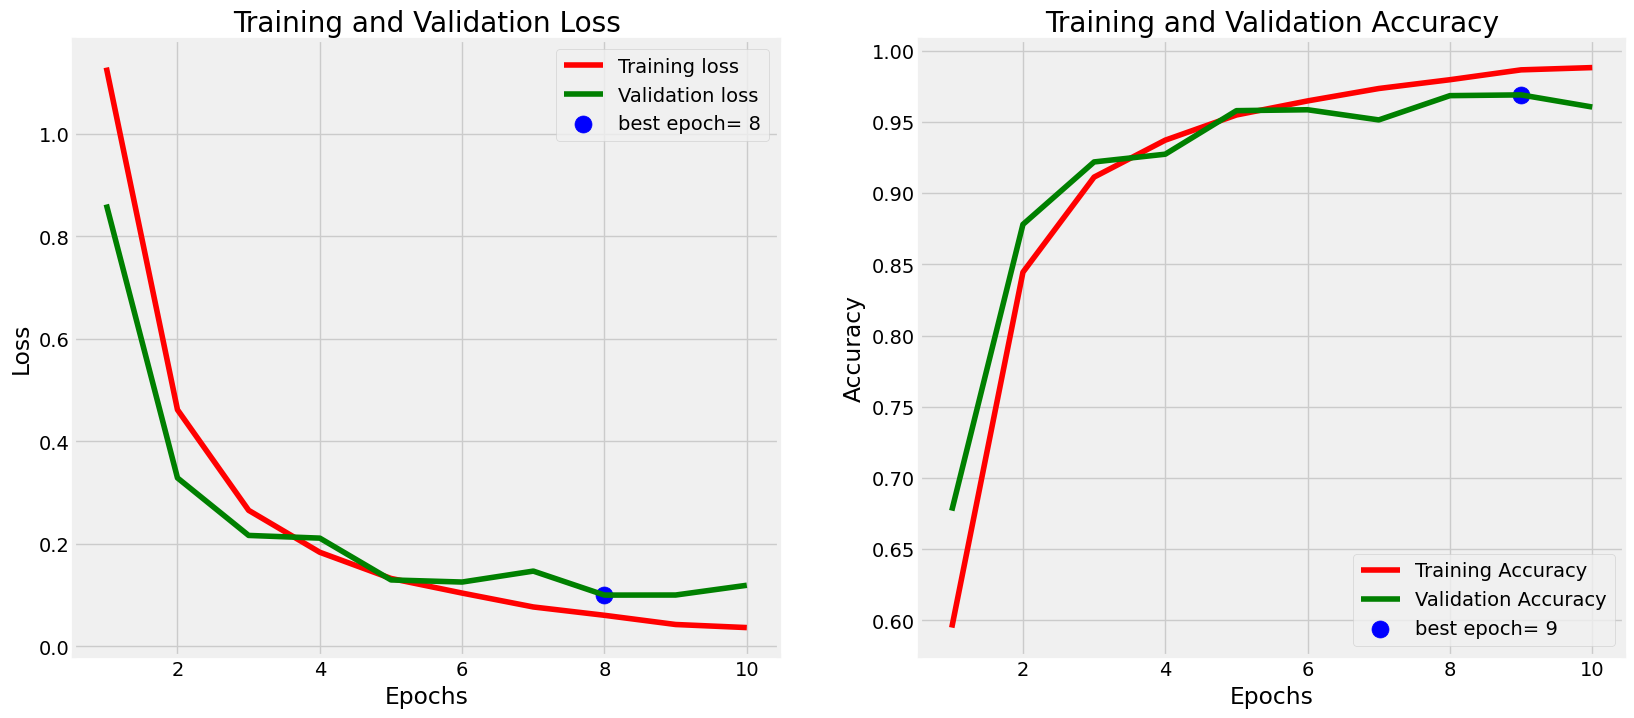

In [ ]:
plot_training(historyA)

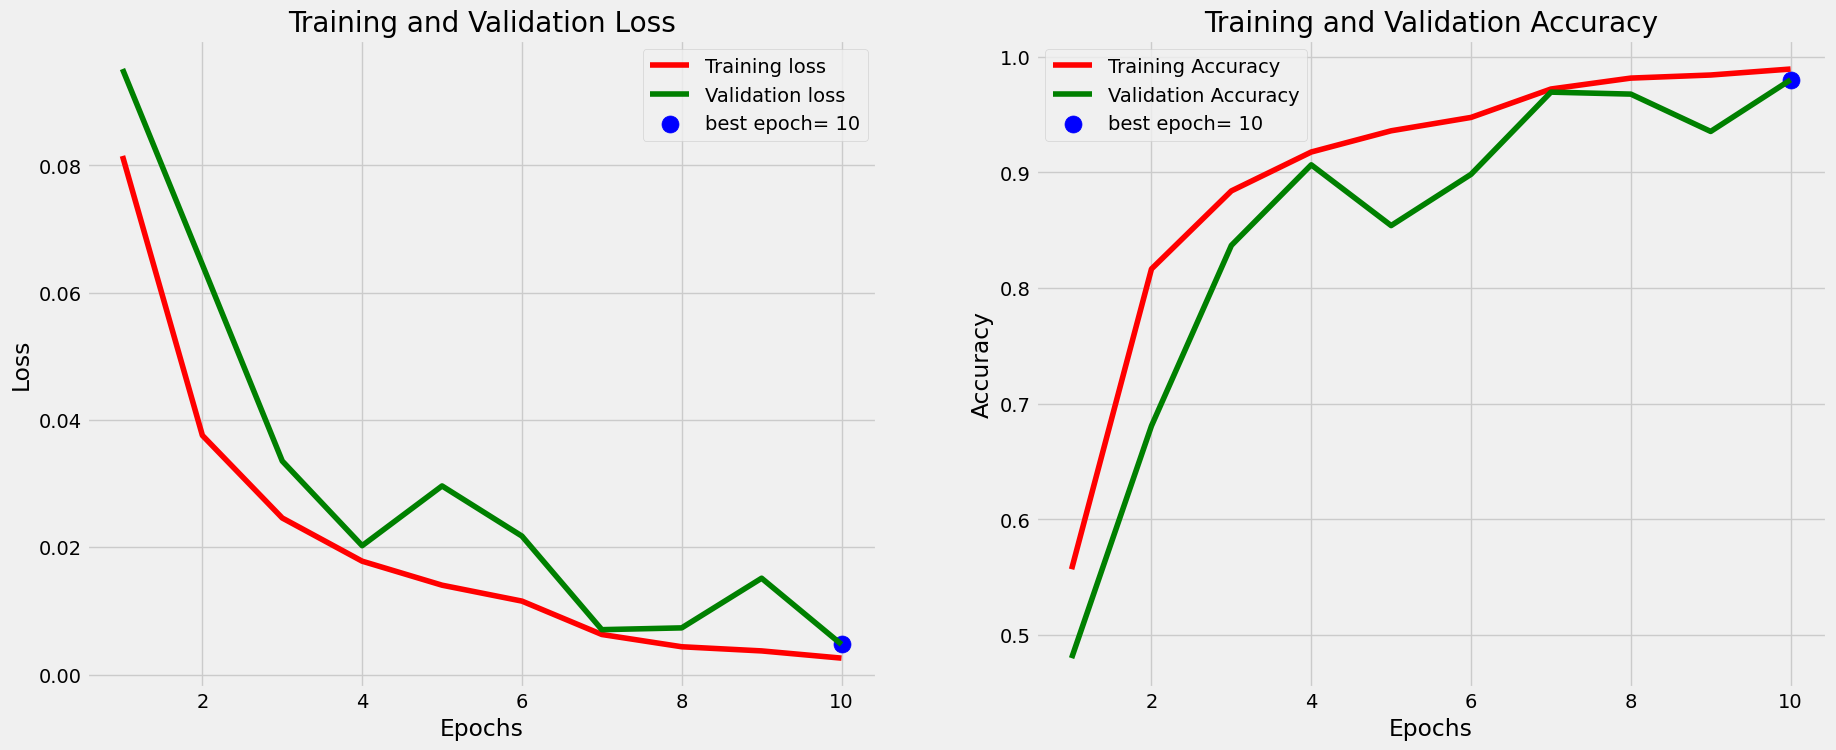

In [ ]:
plot_training(historyB)

In [ ]:
predictions_A = modelA.predict(X_test)
predictions_B = modelB.predict(X_test)

294/294 ━━━━━━━━━━━━━━━━━━━━ 16s 52ms/step
294/294 ━━━━━━━━━━━━━━━━━━━━ 16s 53ms/step


In [ ]:
ensemble_predictions = (predictions_A + predictions_B) / 2

In [ ]:
from sklearn.metrics import accuracy_score

# Assuming y_test is not one-hot encoded for multiclass classification
true_labels = np.argmax(y_test, axis=1)

# If your models are for classification, you might want to convert the probabilities to class predictions
ensemble_class_predictions = np.argmax(ensemble_predictions, axis=1)

# Now you can evaluate the ensemble predictions
ensemble_accuracy = accuracy_score(true_labels, ensemble_class_predictions)
print(f"Ensemble Accuracy: {ensemble_accuracy:.4f}")

NameError: name 'ensemble_predictions' is not defined

In [ ]:
modelA.save("modelA_saved.keras")
modelB.save("modelB_saved.keras")

In [ ]:
modelA_path = '/content/drive/MyDrive/project_dataset/Models/modelA_saved.keras'
modelB_path = '/content/drive/MyDrive/project_dataset/Models/modelB_saved.keras'

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Average
from keras.layers import LeakyReLU

#Loading trained model
# modelA = tf.keras.models.load_model("modelA_saved.keras", custom_objects={'LeakyReLU': LeakyReLU})
# modelB = tf.keras.models.load_model("modelB_saved.keras", custom_objects={'LeakyReLU': LeakyReLU})

#Loading model saved in drive storage
modelA = tf.keras.models.load_model(modelA_path, custom_objects={'LeakyReLU': LeakyReLU})
modelB = tf.keras.models.load_model(modelB_path, custom_objects={'LeakyReLU': LeakyReLU})

# Alternatively, if you saved in HDF5 format
# modelA = tf.keras.models.load_model("modelA.h5")
# modelB = tf.keras.models.load_model("modelB.h5")

# Create input layer
input_shape = (28, 28, 3)  # Adjust to match your model's input shape
inputs = Input(shape=input_shape)

# Get predictions from both models
predA = modelA(inputs)
predB = modelB(inputs)

# Average the predictions
ensemble_output = Average()([predA, predB])

# Create the ensemble model
ensemble_model = Model(inputs=inputs, outputs=ensemble_output)

# Save the ensemble model as a SavedModel or HDF5 file
ensemble_model.save("ensemble_model_saved.keras")
# or
# ensemble_model.save("ensemble_model.h5")

/usr/local/lib/python3.10/dist-packages/keras/src/saving/saving_lib.py:576: UserWarning: Skipping variable loading for optimizer 'rmsprop', because it has 40 variables whereas the saved optimizer has 78 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


In [ ]:
import tensorflow as tf

In [ ]:
#Loading emsemble model
# ensemble_model = tf.keras.models.load_model("ensemble_model_saved.keras", custom_objects={'LeakyReLU': LeakyReLU})

#Loading ensemble model saved in drive storage
ensemble_path = "/content/drive/MyDrive/project_dataset/Models/ensemble_model_saved.keras"
ensemble_model = tf.keras.models.load_model(ensemble_path, custom_objects={'LeakyReLU': LeakyReLU})

In [ ]:
converter = tf.lite.TFLiteConverter.from_keras_model(ensemble_model)
tflite_model = converter.convert()

# Save the ensemble TensorFlow Lite model
with open("ensemble_model.tflite", 'wb') as f_ensemble:
    f_ensemble.write(tflite_model)

Saved artifact at '/tmp/tmp2wb9nrux'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 28, 28, 3), dtype=tf.float32, name='input_layer_2')
Output Type:
  TensorSpec(shape=(None, 7), dtype=tf.float32, name=None)
Captures:
  135425215661504: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135425215668544: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135425215926288: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135425215930336: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135425215927344: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135425215929456: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135425215934032: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135425215937376: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135425215937552: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135425215745184: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135425215747296

In [ ]:
import numpy as np
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Assuming you have X_test and y_test
# X_test: Test data
# y_test: True labels for the test data

# Load the ensemble TensorFlow Lite model
interpreter = tf.lite.Interpreter(model_content=tflite_model)
interpreter.allocate_tensors()

# Get input and output details
input_details = interpreter.get_input_details()[0]
output_details = interpreter.get_output_details()[0]

# Run predictions on the test data
predictions = []
for sample in X_test:
    sample = np.expand_dims(sample, axis=0).astype(np.float32)
    interpreter.set_tensor(input_details['index'], sample)
    interpreter.invoke()
    output_data = interpreter.get_tensor(output_details['index'])
    predictions.append(output_data)

predictions = np.vstack(predictions)

# Convert predictions to class labels
predicted_labels = np.argmax(predictions, axis=1)

# Convert true labels to class labels
true_labels = np.argmax(y_test, axis=1)

# Calculate evaluation scores
accuracy = accuracy_score(true_labels, predicted_labels)
precision = precision_score(true_labels, predicted_labels, average='weighted')
recall = recall_score(true_labels, predicted_labels, average='weighted')
f1 = f1_score(true_labels, predicted_labels, average='weighted')

print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-Score: {f1:.4f}")

Accuracy: 0.9846
Precision: 0.9846
Recall: 0.9846
F1-Score: 0.9844


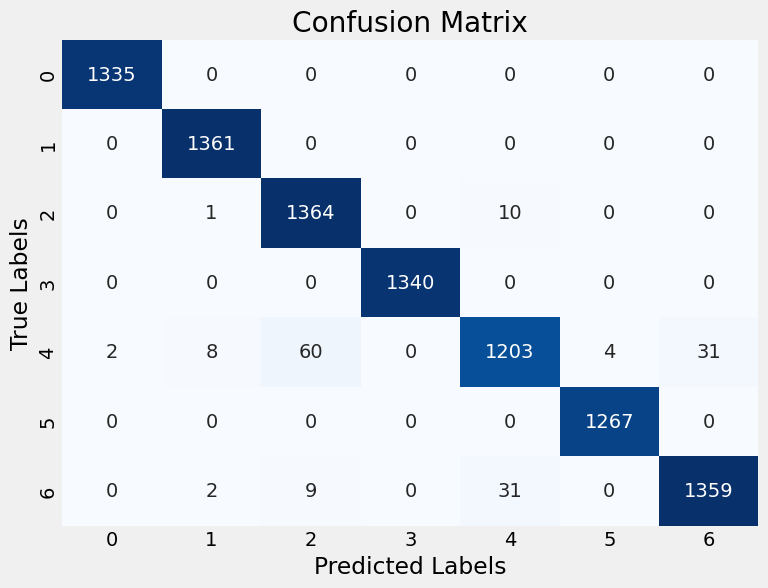

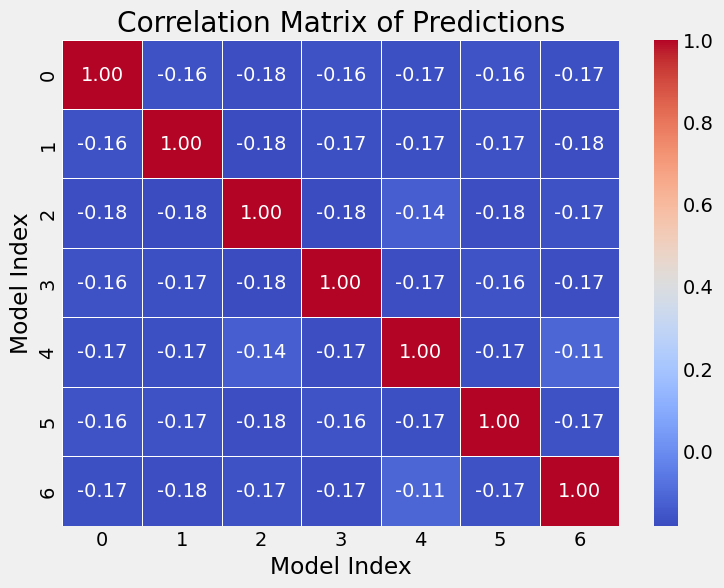

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Assuming you have true_labels and predicted_labels from the previous example
# true_labels: True class labels
# predicted_labels: Predicted class labels

# Confusion Matrix
cm = confusion_matrix(true_labels, predicted_labels)

# Plot the Confusion Matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False)
plt.title("Confusion Matrix")
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.show()

# Correlation Matrix
correlation_matrix = np.corrcoef(predictions.T)

# Plot the Correlation Matrix
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Correlation Matrix of Predictions")
plt.xlabel("Model Index")
plt.ylabel("Model Index")
plt.show()

Model: "functional_151"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)              ┃ Output Shape           ┃        Param # ┃ Connected to           ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1             │ (None, 28, 28, 3)      │              0 │ -                      │
│ (InputLayer)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ sequential (Sequential)   │ (None, 7)              │      1,275,079 │ input_layer_1[0][0]    │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ sequential_1 (Sequential) │ (None, 7)              │      1,275,079 │ input_layer_1[0][0]    │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ average_1 (Average)       │ (None, 7)              │              0 │ sequential[0][0],      │
│                           │                        │                │ sequential_1[0][0]     │
└───────────────────────────┴────────────────────────┴────────────────┴────────────────────────┘

 Total params: 2,550,158 (9.73 MB)

 Trainable params: 2,547,342 (9.72 MB)

 Non-trainable params: 2,816 (11.00 KB)

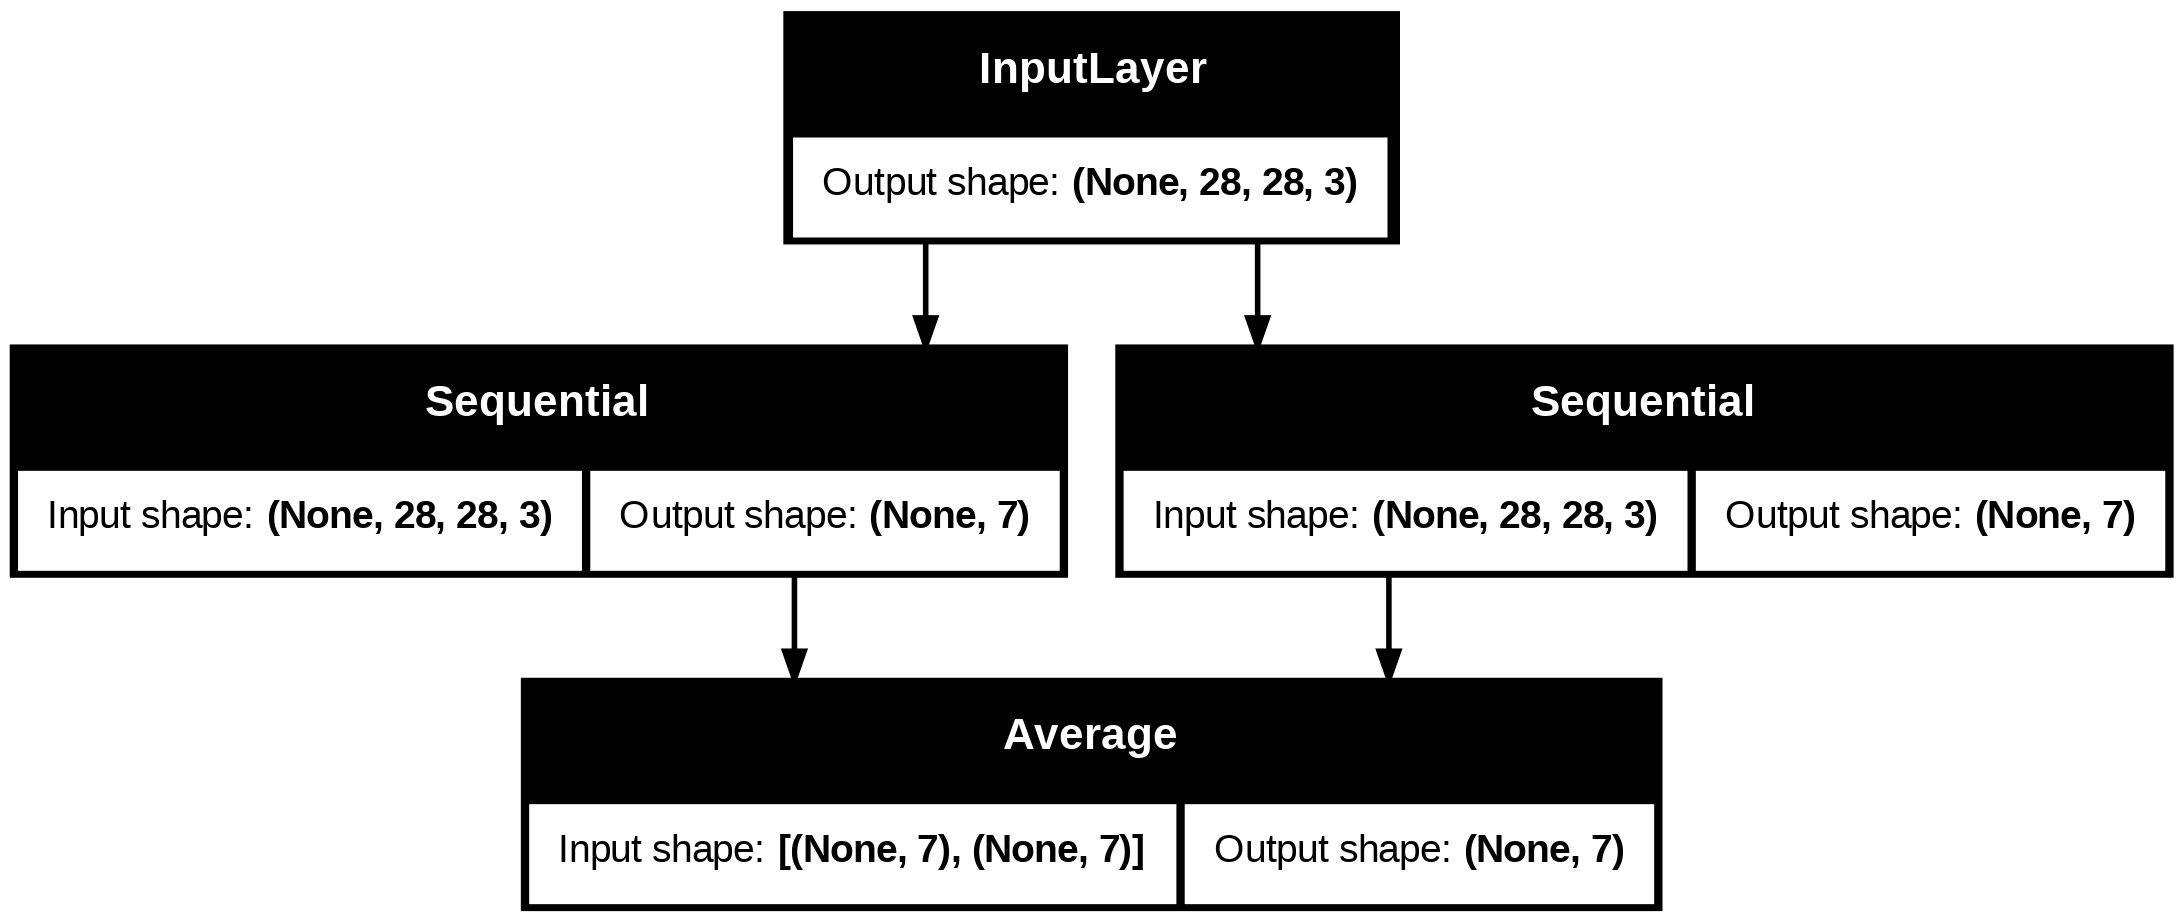

In [ ]:
import tensorflow as tf

# Load your original Keras/TensorFlow model
model = tf.keras.models.load_model('ensemble_model_saved.keras', custom_objects={'LeakyReLU': LeakyReLU})

# Print the model summary
model.summary()

# Generate a plot of the model architecture
tf.keras.utils.plot_model(model, to_file="model_architecture.png", show_shapes=True)


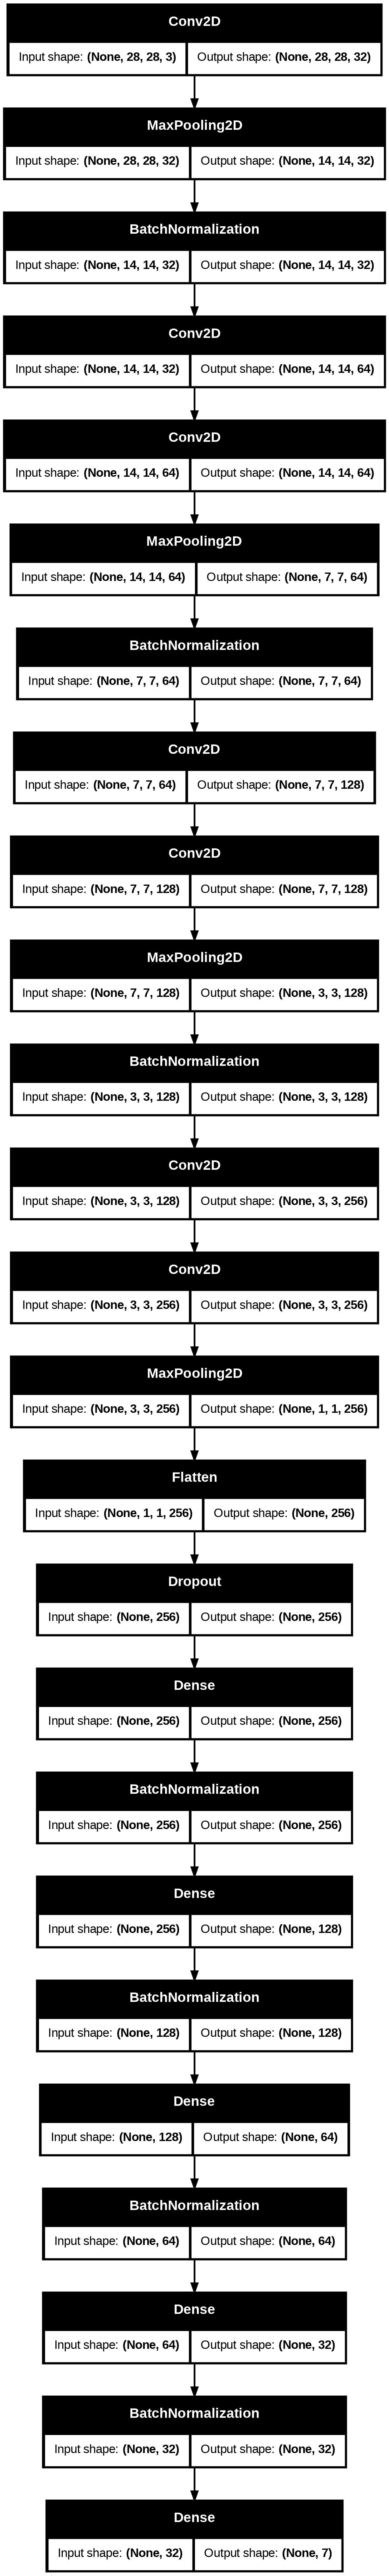

In [ ]:
tf.keras.utils.plot_model(modelA, to_file="modelA_architecture.png", show_shapes=True)

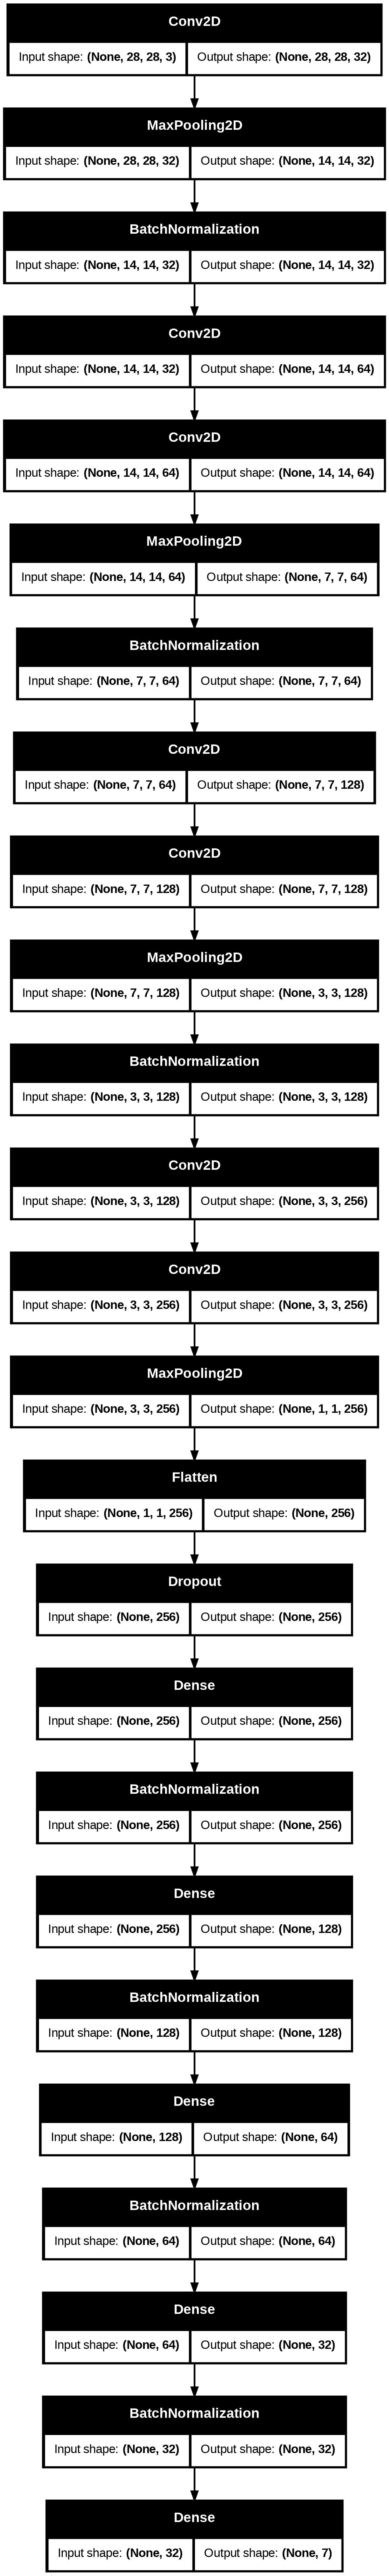

In [ ]:
tf.keras.utils.plot_model(modelB, to_file="modelB_architecture.png", show_shapes=True)

In [ ]:
# Load modelA
# modelA = keras.models.load_model("modelA.keras")

# Make predictions with modelA
predictionsA = modelA.predict(X_test)

# Convert predictions to class labels
predicted_labelsA = np.argmax(predictionsA, axis=1)
true_labels = np.argmax(y_test, axis=1)  # Convert true labels to class labels

# Calculate evaluation scores for modelA
accuracyA = accuracy_score(true_labels, predicted_labelsA)
precisionA = precision_score(true_labels, predicted_labelsA, average='weighted')
recallA = recall_score(true_labels, predicted_labelsA, average='weighted')
f1A = f1_score(true_labels, predicted_labelsA, average='weighted')

print(f"ModelA Accuracy: {accuracyA:.4f}")
print(f"ModelA Precision: {precisionA:.4f}")
print(f"ModelA Recall: {recallA:.4f}")
print(f"ModelA F1-Score: {f1A:.4f}")

294/294 ━━━━━━━━━━━━━━━━━━━━ 26s 90ms/step
ModelA Accuracy: 0.9652
ModelA Precision: 0.9657
ModelA Recall: 0.9652
ModelA F1-Score: 0.9650


In [ ]:
# Load modelB
# modelB = tf.keras.models.load_model("modelB.keras")

# Run predictions for modelB
predictionsB = modelB.predict(X_test)

# Convert modelB predictions to class labels
predicted_labelsB = np.argmax(predictionsB, axis=1)

# Calculate evaluation scores for modelB
accuracyB = accuracy_score(true_labels, predicted_labelsB)
precisionB = precision_score(true_labels, predicted_labelsB, average='weighted')
recallB = recall_score(true_labels, predicted_labelsB, average='weighted')
f1B = f1_score(true_labels, predicted_labelsB, average='weighted')

print(f"ModelB Accuracy: {accuracyB:.4f}")
print(f"ModelB Precision: {precisionB:.4f}")
print(f"ModelB Recall: {recallB:.4f}")
print(f"ModelB F1-Score: {f1B:.4f}")

294/294 ━━━━━━━━━━━━━━━━━━━━ 16s 54ms/step
ModelB Accuracy: 0.9816
ModelB Precision: 0.9815
ModelB Recall: 0.9816
ModelB F1-Score: 0.9814
